# Power Transformation on Concrete Strength Dataset

## Introduction

In many real-world regression problems, numerical features are often skewed and do not follow a normal distribution. Skewness can negatively impact the performance of linear and distance-based machine learning models.

In this notebook, we apply power transformation techniques to the Concrete Compressive Strength dataset to reduce skewness, stabilize variance, and improve model performance.

---

## Problem Context

The Concrete Strength dataset contains numerical variables such as:

- Cement
- Blast Furnace Slag
- Fly Ash
- Water
- Superplasticizer
- Coarse Aggregate
- Fine Aggregate
- Age

These features may exhibit skewed distributions, which can affect regression models.

---

## Objective

- Identify skewed features  
- Apply appropriate power transformation techniques  
- Compare distributions before and after transformation  
- Analyze the impact on model performance  

---

## Why Power Transformation?

Many regression models assume:

- Normally distributed errors  
- Constant variance  
- Linear relationships  

Power transformations help bring the data closer to these assumptions.

---

## Techniques Applied

- Log Transformation  
- Box-Cox Transformation  
- Yeo-Johnson Transformation  

---

## Expected Outcome

After applying transformation:

- Reduced skewness  
- More symmetric distributions  
- Improved regression performance  

---

## Important Note

> ⚠️ Box-Cox transformation requires strictly positive values, while Yeo-Johnson can handle zero and negative values.

### Import requirements 

In [31]:
import pandas as pd 
import numpy as np
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import PowerTransformer
import warnings
warnings.filterwarnings('ignore')

In [28]:
df=pd.read_csv('concrete_data.csv')
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [6]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [7]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [10]:
df.shape

(1030, 9)

In [13]:
X=df.drop(['Strength'],axis=1)
y=df['Strength']

In [14]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
lr=LinearRegression()

In [16]:
lr.fit(X_train,y_train)

LinearRegression()

In [17]:
y_pred=lr.predict(X_test)

In [18]:
r2_score(y_test,y_pred)

0.6275531792314851

## #cross_val_score()

-This function comes from sklearn.model_selection.

-It performs Cross-Validation, a technique used to evaluate how well a machine learning model generalizes to unseen data.

In [19]:
# cross valadition score 
np.mean(cross_val_score(lr,X,y,scoring='r2'))

0.46099404916628667

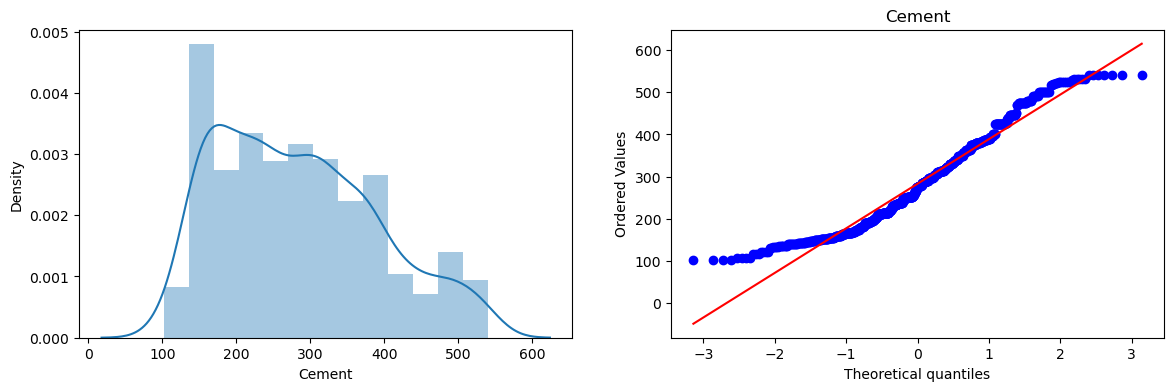

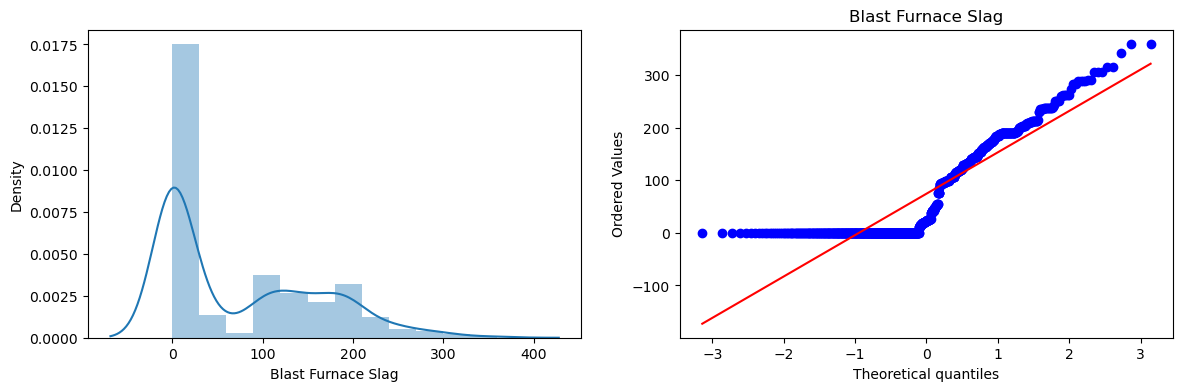

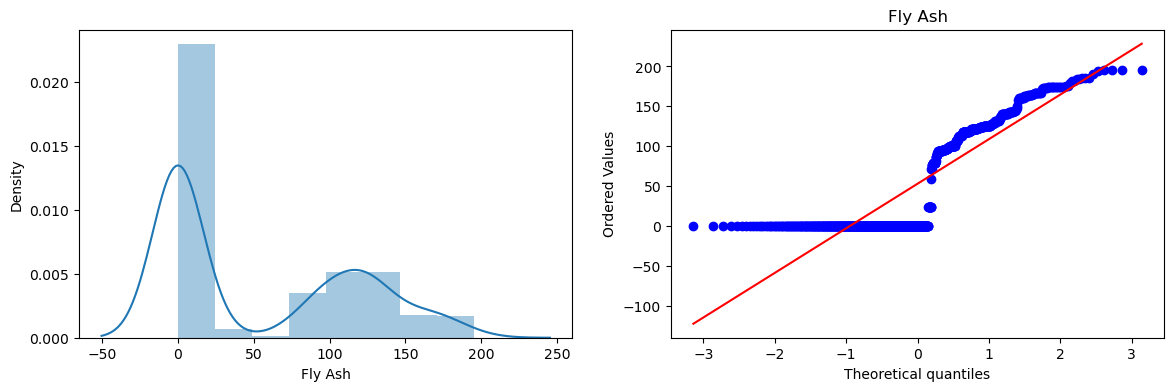

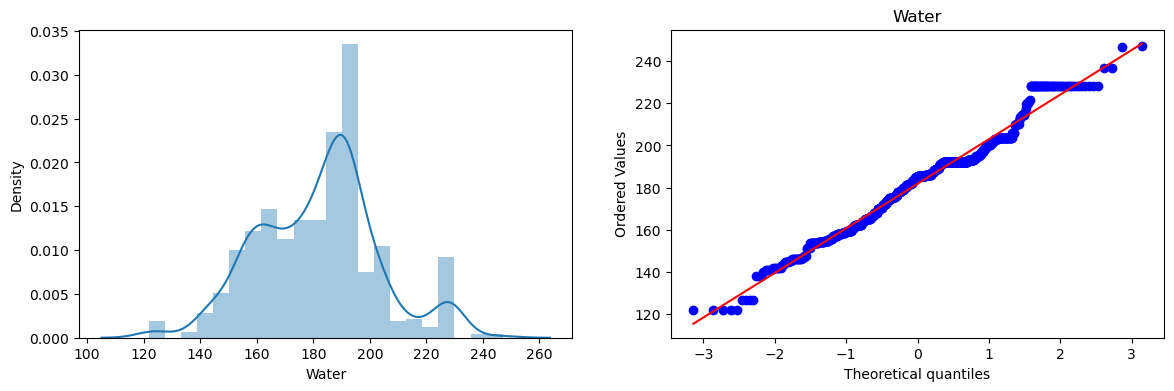

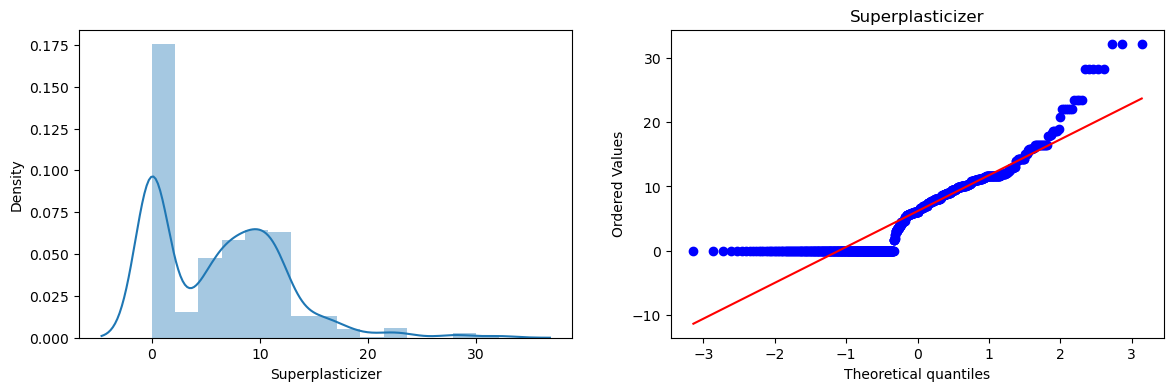

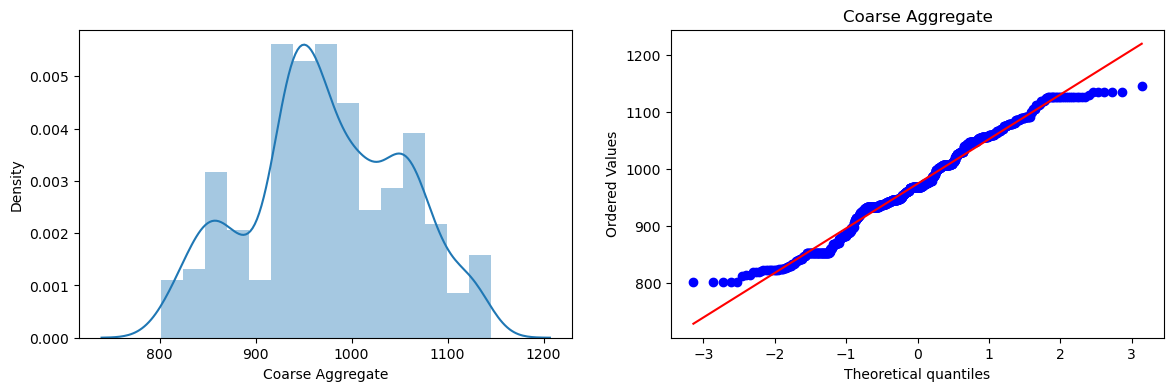

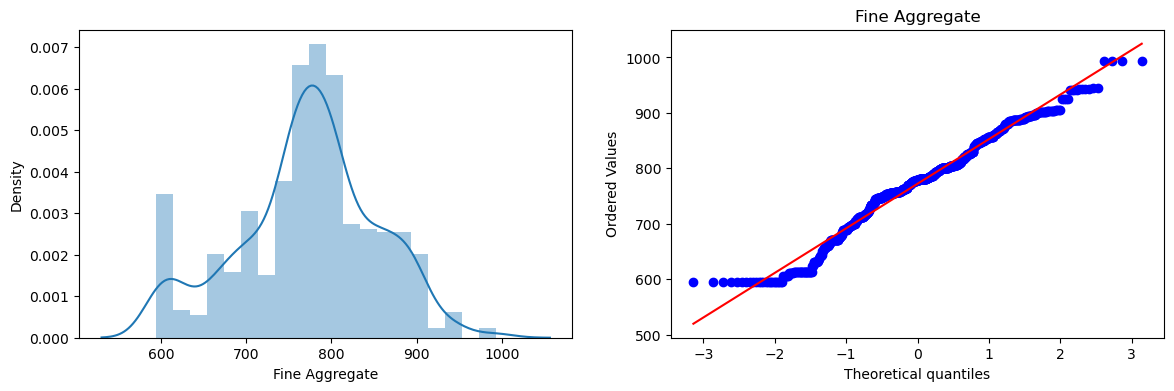

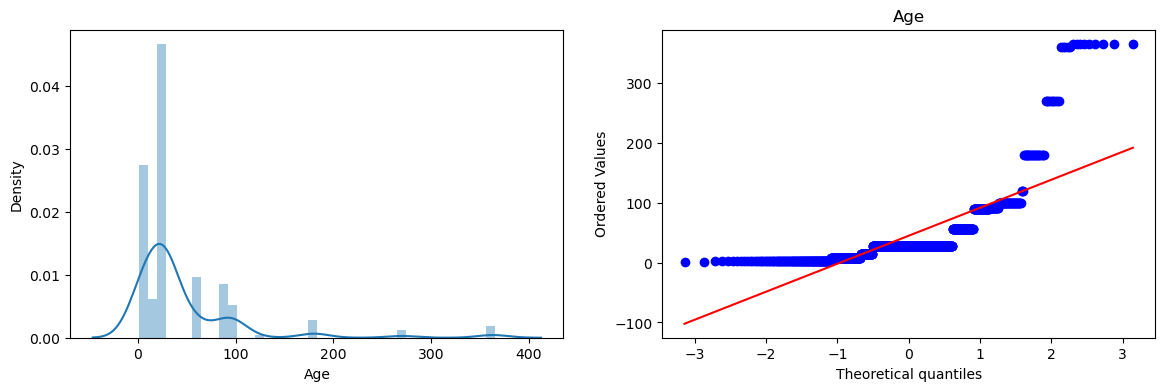

In [25]:
# Check the distribution of each features in dataset
for col in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.distplot(X_train[col])


    plt.subplot(122)
    stats.probplot(X_train[col],dist='norm',plot=plt)
    plt.title(col)
    plt.show()

# Box-Cox
The Box-Cox transform is a statistical technique used to make data more normally distributed (reduce skewness) by applying a power transformation to each data value.

In [34]:
pt = PowerTransformer(method='box-cox')

In [37]:
X_train_transform=pt.fit_transform(X_train+0.000001)
X_test_transform=pt.fit_transform(X_test+0.000001)

In [38]:
pd.DataFrame({'cols':X_train.columns,'box-cox_labdas':pt.lambdas_})

,cols,box-cox_labdas
0,Cement,0.215602
1,Blast Furnace Slag,0.025996
2,Fly Ash,-0.006544
3,Water,0.959062
4,Superplasticizer,0.103365
5,Coarse Aggregate,1.192492
6,Fine Aggregate,1.973781
7,Age,-0.014692


In [39]:
lr=LinearRegression()

In [40]:
lr.fit(X_train_transform,y_train)

LinearRegression()

In [46]:
y_pred1=lr.predict(X_test_transform)

In [47]:
r2_score(y_test,y_pred1)

0.8055320999414498

In [48]:
X_tranform=pt.fit_transform(X+0.000001)

In [49]:
np.mean(cross_val_score(lr,X_tranform,y,scoring='r2'))

0.6662950319746161

In [51]:
# After Box_cox transformation 
X_train_transformd=pd.DataFrame(X_test_transform,columns=X_train.columns)
X_train_transformd.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,0.060677,0.921270,-0.980502,2.197654,-1.316803,-0.525879,-1.395916,2.190544
1,1.008971,0.990754,-0.980502,-0.732593,0.813137,-0.354835,-0.356595,-1.008854
2,1.240476,0.990754,-0.980502,-1.623284,0.992126,-0.354835,-0.356595,0.134094
3,1.008971,0.990754,-0.980502,-0.732593,0.813137,-0.354835,-0.356595,-1.718968
4,-1.622742,-1.088406,1.065419,0.994905,0.714532,-1.961798,1.200661,0.134094


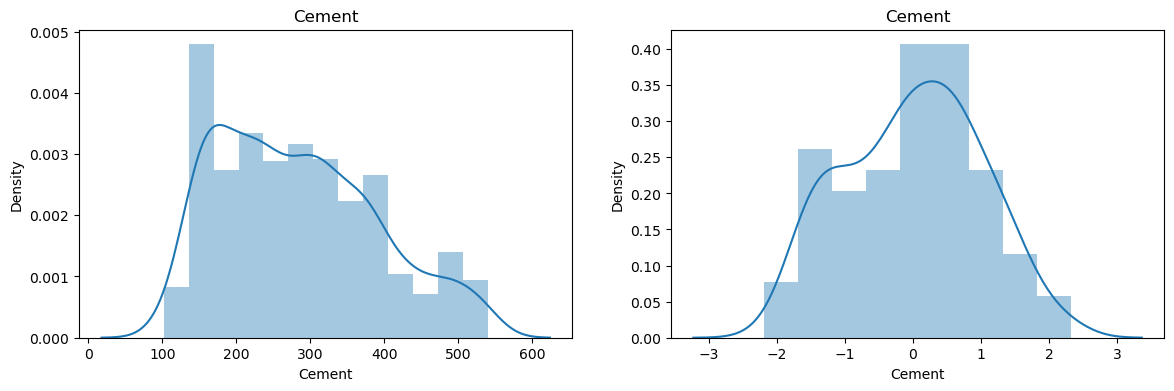

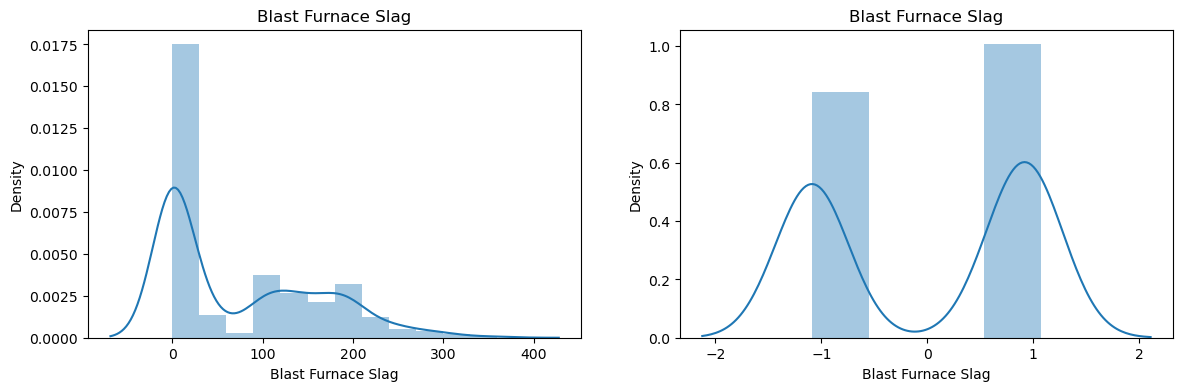

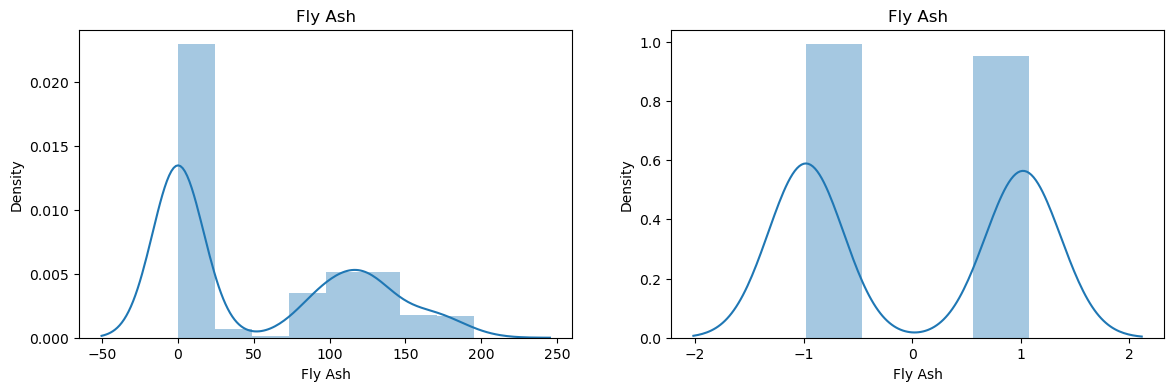

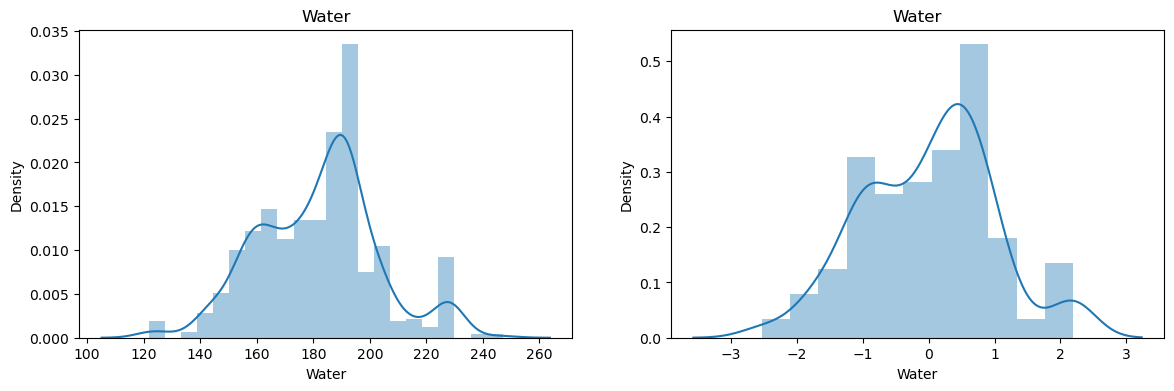

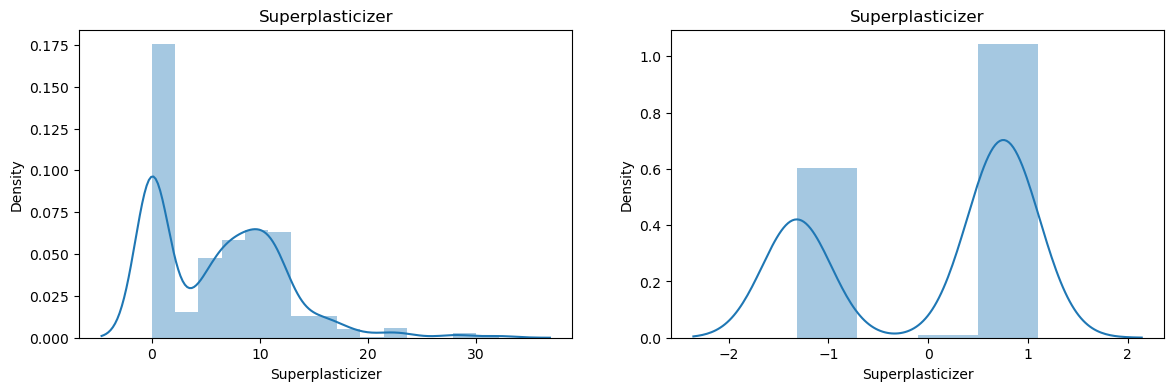

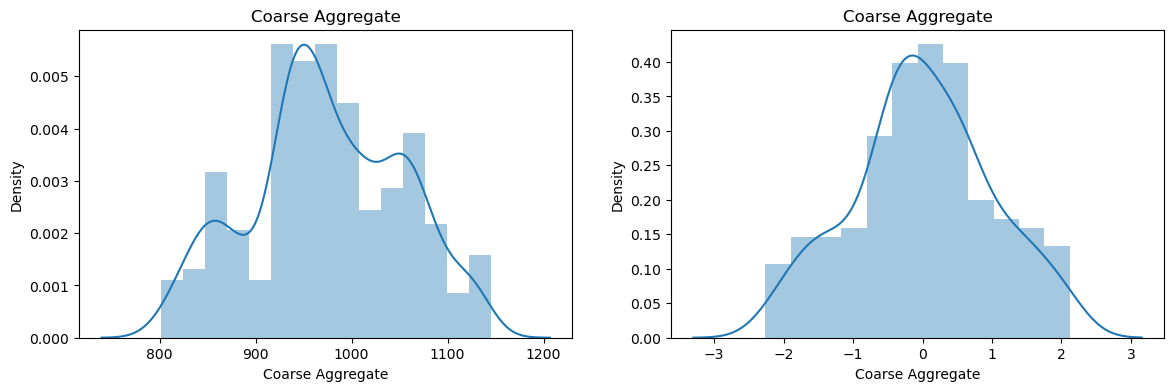

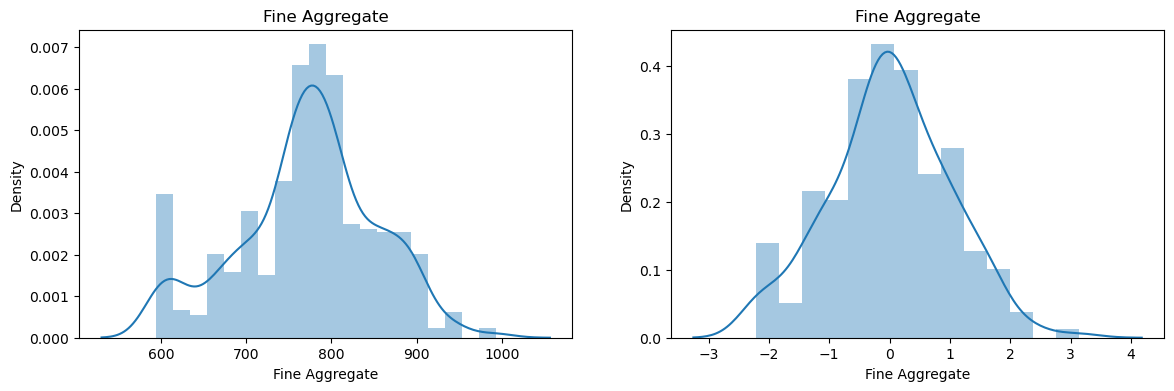

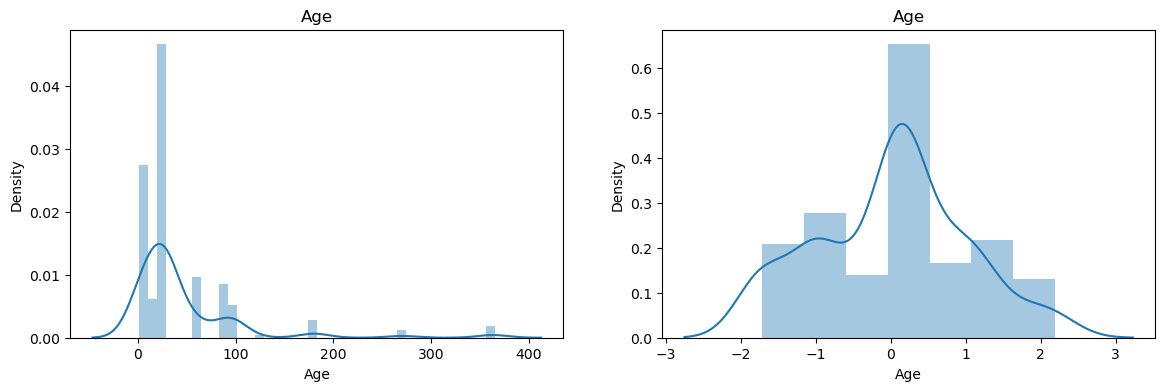

In [54]:
for col in X_train_transformd.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.distplot(X_train[col])
    plt.title(col)


    plt.subplot(122)
    sns.distplot(X_train_transformd[col])
    plt.title(col)
    plt.show()

### Yeo-johnson
The Yeo–Johnson transform is a power transformation (like Box–Cox) used to make data more normally distributed,
but unlike Box–Cox, it works for both positive and negative values.

In [55]:
pt1=PowerTransformer()

In [57]:
X_train_transform2=pt1.fit_transform(X_train)
X_test_transform2=pt1.fit_transform(X_test)

In [58]:
lr=LinearRegression()

In [59]:
lr.fit(X_train_transform2,y_train)

LinearRegression()

In [60]:
Y_pred2=lr.predict(X_test_transform2)

In [61]:
r2_score(y_test,Y_pred2)

0.8153845515001845

In [62]:
X_tranform2=pt1.fit_transform(X)

In [63]:
np.mean(cross_val_score(lr,X_tranform2,y,scoring='r2'))

0.6834625134285744